# Lab 1.1: Graph Regularization

In this lab, you will learn how to perform graph-based machine learning via regularization techniques.
The specific objectives are:

*   Implement different graph-based regularization techniques to perform node-wise signal regression.
*   Analyze the trade-off between fitting and regularization.
*   Explain the perfromance of particular regularizer.

**Completion requirements**

*   Showing the graph sparsity as a function of abstract network hyper-parameters.
*   Implementing and analyzing two regularizers for signal denosing and reconstruction. 
 



## Dataset and problem definition

To achieve the above objectives, we will work with a real-world weather dataset called **Molene**.
This dataset contains weather temperature over 32 distinct stations in France recorded for a month with hourly resolution.
We will treat each time instant as a graph signal and aim to recover it from noisy measurments and signals with missing values.
For this, we will compare two regularization techniques:
*   Tikhonov regularizer
$$
\hat{\textbf{x}} = \text{arg}\min_{\textbf{x}} \|\textbf{y} - \textbf{x}\|_2^2 + \alpha \textbf{x}^T\textbf{L}\textbf{x}
$$

*   Trend filtering.
$$
\hat{\textbf{x}} = \text{arg}\min_{\textbf{x}} \|\textbf{y} - \textbf{x}\|_2^2 + \beta \|\textbf{B}^T\textbf{x}\|_1,
$$
where $\textbf{B}$ is the indcidence matrix of the graph.

## Libraries

* Numpy
* Pandas
* PyGSP or NetwrokX (or any other viable libraries)
* Scikit-learn
* Matplotlib
* CVXPy and CVXOPT (or any other optimization solver library)

In [1]:
import numpy as np
import pandas as pd
from pygsp import graphs, plotting
import matplotlib.pyplot as plt
import cvxpy as cp
import cvxopt as cvxopt

## Building the graph

We can treat each sensor as a node of a graph and the temperatures as signals over these nodes.
These sensors have also metadata such as their geolocation.
We can therefore build an abstract network connecting them.
This network can for instance be build using these metadata or using a portion of the time series and connecting nodes based on their statistical dependencies in them (e.g. Pearson correlation).
In either case, you could use different criteria to connect the nodes such as $k$-nearest neighbors, $\epsilon$-ball graph, etc.
*It is up to you to build any graph from any data* 

### Task 1

Build a **connected** and **sparse** graph between sensors.
Choose your hyperparameters to achieve at least 80% sparsity ($\frac{\text{zeros of } \textbf{A}}{N^2}$).
If you cannot ensure a connected graph with such a sparsity factor it can also be less sparse.
Tune your hyper parameters accordingly.

In [2]:
## Reading metadata of the stations
stations_metadata = pd.read_csv('lab1_molene/weather_stations_filtered_Molene.csv',index_col=0)
stations_metadata

,Numéro,Nom,Latitude,Longitude,Lambert II X,Lambert II Y,Altitude
0,22016001,ILE-DE-BREHAT,48°51'18N,3°00'12W,24419,2081,25
1,22092001,KERPERT,48°24'12N,3°08'48W,23925,1941,281
3,22135001,LOUARGAT,48°33'06N,3°22'36W,24101,1784,148
4,22147006,MERDRIGNAC,48°10'54N,2°24'36W,23644,2471,131
5,22168001,PLOUMANAC'H,48°49'30N,3°28'18W,24410,1735,55
6,22219003,PLOUGUENAST,48°15'54N,2°44'54W,23752,2226,235
7,22247002,POMMERIT-JAUDY,48°44'30N,3°15'00W,24306,1891,55
8,22261002,QUINTENIC,48°31'06N,2°25'12W,24018,2487,71
9,22266001,ROSTRENEN,48°13'48N,3°18'24W,23742,1809,262
10,22282001,SAINT-CAST-LE-G,48°38'36N,2°14'48W,24149,2622,35


In [3]:
## extracting the coordinates for each station from the metadata => these coordinates can be treated as distance
coordinates_df = stations_metadata.iloc[:,-3:]  
coordinates_df = coordinates_df - coordinates_df.mean() # => Removing mean to have more tangible coordinates
coordinates = coordinates_df.to_numpy()


Is connected:  True


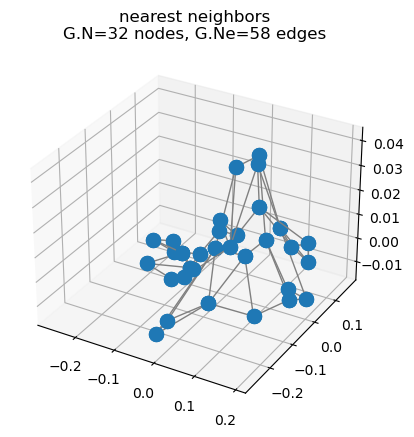

In [4]:
## Add your code here
## You can PyGSP or NetwrokX pakcage for this to have predefined graph builders.

# At k = 3 the graph is connected
G = graphs.NNGraph(coordinates, k=3)
print("Is connected: ", G.is_connected())

plotting.plot(G)

### Question 1
What type of graph did you use and what is the hyperparameter of it?
Make a plot of the graph sparsity as a function of at least one hyper parameter.
Make sure the graph remains connected.

**Answer**:
<font color = 'red'>
I used a k nearest neighbour graph where the hyperparameter is k (the number of nearest neighbours we connect to)
For k < 2 we lose a fully connected graph.

In [5]:
## Add your code here

nn = 32 * 32
sparsities = []
for i in range(3, 32):
    G = graphs.NNGraph(coordinates, k=i)
    
    # Compute sparsity 
    sparsity = np.sum(G.A) / nn
    sparsities.append((i, sparsity))

print(sparsities)

[(3, 0.11328125), (4, 0.158203125), (5, 0.193359375), (6, 0.236328125), (7, 0.27734375), (8, 0.30859375), (9, 0.34765625), (10, 0.376953125), (11, 0.412109375), (12, 0.443359375), (13, 0.482421875), (14, 0.521484375), (15, 0.55078125), (16, 0.59765625), (17, 0.638671875), (18, 0.673828125), (19, 0.71875), (20, 0.751953125), (21, 0.78125), (22, 0.8125), (23, 0.841796875), (24, 0.8671875), (25, 0.892578125), (26, 0.912109375), (27, 0.931640625), (28, 0.947265625), (29, 0.95703125), (30, 0.966796875), (31, 0.96875)]


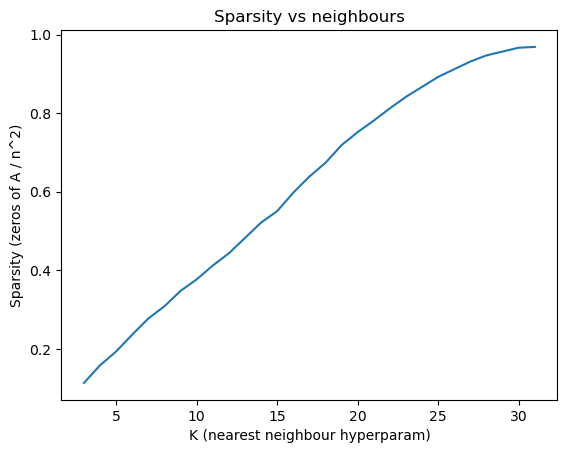

In [6]:
x = [sparsity[0] for sparsity in sparsities] 
y = [sparsity[1] for sparsity in sparsities]

plt.plot(x, y)
plt.xlabel("K (nearest neighbour hyperparam)")
plt.ylabel("Sparsity (zeros of A / n^2)")
plt.title("Sparsity vs neighbours")
plt.show()

## Noisy measurements

Let $e$ be the average energy of the graph signals in the dataset.
$$
e = \frac{1}{m} \sum_{i=1}^m \|\textbf{x}_i\|_2^2,
$$
where $m$ is the number of data points.
Generate $m$ noisy graph signal $\textbf{y} = \textbf{x} + \textbf{n}$ where $\textbf{n}$ is a zero-mean Gaussian noise $\textbf{n} \sim \mathcal{N}(0,σ^2\textbf{I})$.
Consider $\sigma^2 = e/2$.

In [58]:
## loading the data
timeseries_data = pd.read_csv('lab1_molene/filtered_data_Molene.csv', index_col = 'date', parse_dates = True)
timeseries_data = timeseries_data - timeseries_data.mean() # => removing mean from data

In [59]:
x = timeseries_data.to_numpy().transpose()  # => transpose the data so we have each column as a graph signal

e = np.sum(np.square(x))/x.shape[1] # computing average energy

sigma = e/x.shape[0]/2
n = np.random.multivariate_normal(np.zeros(x.shape[0]), sigma * np.eye(x.shape[0]), size=x.shape[1]).transpose() # => generating noise

y = x + n   # adding to noise to synthesize noisy observations

### Task 2

Use the Tikhonov regularizer for a choice of $\alpha > 0$ to recover signal $\textbf{x}$ from the measurements $\textbf{y}$.
Provide the signal recovery metric root normalized mean square error (rNMSE)
$$
\text{rNMSE} = \left(\frac{\sum_{i=1}^m \|\hat{\textbf{x}}_i-\textbf{x}_i\|_2^2}{\sum_{i=1}^m\|\textbf{y}_i\|_2^2}
\right)^{0.5}
$$

In [60]:
## set the regularizer coefficient
alpha = 1

## exploit the graph Laplacian (if you are using pygsp, convert it to dense format from sparse for further computations(use .todense()).
# laplacian is Adjacency Degree - Adjacency
L = G.L.todense()

## write down the closed form solution for Tikhonov regularizer
# Closed form is (MM^T + alpha L)^-1 MM^T y
# We have full observations so we know that M is basically the Identity matrix
# Then MM^T gives I
# So the closed form solution is: (I + alpha L)^-1 I y

MMt = np.eye(*L.shape)
x_hat = np.matmul(np.linalg.inv(MMt + alpha * L), y) 

rnmse = np.sqrt(np.square(x_hat - x).mean()) / y.std()  # rnmse definition

print(f"The rNMSE is: {np.round(rnmse,4)}")

The rNMSE is: 0.3193


### Question 2

Illustrate rNMSE as a function of $\alpha \in [0,10]$. What do you conclude about the role of the regularizer?




In [61]:
## Add your code here

def compute_rnmse(y, x):
    rnmses = []

    for alpha in range(0, 11):
        x_hat = np.matmul(np.linalg.inv(MMt + alpha * L), y)    
        rnmse = np.sqrt(np.square(x_hat - x).mean()) / y.std()  # rnmse definition

        rnmses.append(rnmse)

    return rnmses 

rnmses = compute_rnmse(y, x)

print(rnmses)

[0.5768248537201234, 0.3193388743732603, 0.3264678240304557, 0.3290873836978341, 0.3304449586624974, 0.3312750880105948, 0.3318350691915096, 0.3322382912404013, 0.3325424855174674, 0.3327801382141578, 0.3329709281648042]


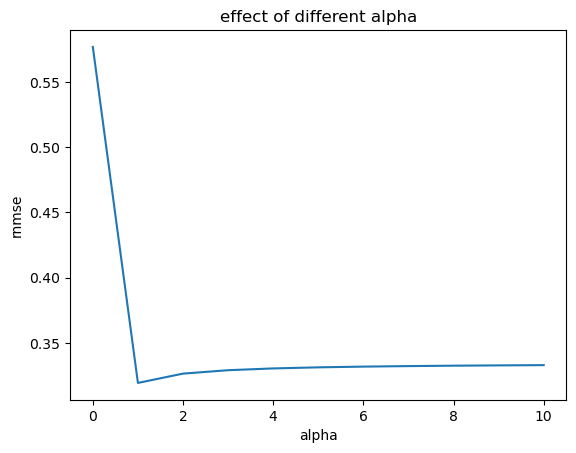

In [63]:
x_coords = [i for i in range(0, 11)]

plt.plot(x_coords, rnmses)
plt.xlabel("alpha")
plt.ylabel("rnmse")
plt.title("effect of different alpha")
plt.show()

**Answer**:
<font color = 'red'>

It seems that an alpha of 0 gives the worst performance, and anything greater or equal to 1 gives basically equal performance. 
The exception is that 1 seems to give the best performance.

If we interpret this in terms of the Tikhonov regularizer with rNMSE as our loss/error:
The Tikhonov regularizer aims to regularize signals in such a way that theyre more smooth, meaning that neighbouring nodes (or nodes close to eachother) are not extremely different, but rather a smooth transition of signal labels exists between them.

We thus observe that having no regularization (no such smoothness) results in worse performance.

This kind of makes sense as our original data is weather temperate in France accross 32 different locations. The temperatures at each location shouldn't differ too much as France is not a very big country. So having very different signals for different nodes does not make sense. Thus using a regularization technique that enforces smoothness of predictions makes a lot of sense here as we expect such a smooth transition for temperature changes between nodes close to eachother (neigbhouring nodes for example, or 2 hop neighbours etc.., basically nodes sufficiently close)

### Question 3

Consider now different noisy scenarios, $\sigma^2 = e/10$ and $\sigma^2 = e$.
Add the respective line into your plot.
What do you conclude about the role of the regularizer?

In [64]:
## Add your code here

variance = e / 10 
n = np.random.multivariate_normal(np.zeros(x.shape[0]), variance * np.eye(x.shape[0]), size=x.shape[1]).transpose()     # => generating noise
y_e10 = x + n                                                                                                           # adding to noise to synthesize noisy observations
rnmses_e10 = compute_rnmse(y, x)


variance = e 
n = np.random.multivariate_normal(np.zeros(x.shape[0]), variance * np.eye(x.shape[0]), size=x.shape[1]).transpose()   # => generating noise
y_e = x + n                                                                                                           # adding to noise to synthesize noisy observations
rnmses_e = compute_rnmse(y, x)

print(rnmses)
print(rnmses_e10)
print(rnmses_e) 

[0.5768248537201234, 0.3193388743732603, 0.3264678240304557, 0.3290873836978341, 0.3304449586624974, 0.3312750880105948, 0.3318350691915096, 0.3322382912404013, 0.3325424855174674, 0.3327801382141578, 0.3329709281648042]
[0.5768248537201234, 0.3193388743732603, 0.3264678240304557, 0.3290873836978341, 0.3304449586624974, 0.3312750880105948, 0.3318350691915096, 0.3322382912404013, 0.3325424855174674, 0.3327801382141578, 0.3329709281648042]
[0.5768248537201234, 0.3193388743732603, 0.3264678240304557, 0.3290873836978341, 0.3304449586624974, 0.3312750880105948, 0.3318350691915096, 0.3322382912404013, 0.3325424855174674, 0.3327801382141578, 0.3329709281648042]


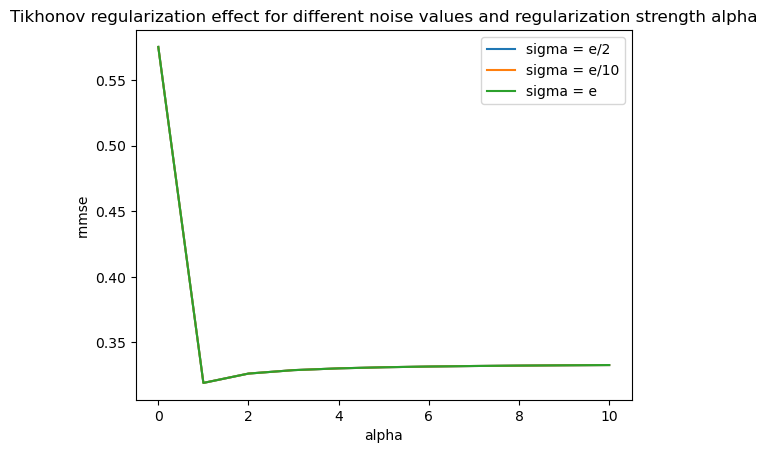

In [48]:
fig, ax = plt.subplots()

ax.plot(x_coords, rnmses, label='sigma = e/2')
ax.plot(x_coords, rnmses_e10, label='sigma = e/10')
ax.plot(x_coords, rnmses_e, label='sigma = e')

ax.set_title('Tikhonov regularization effect for different noise values and regularization strength alpha')
ax.set_xlabel('alpha')
ax.set_ylabel('rnmse')
ax.legend()

plt.show()

**Answer**:
<font color = 'red'>

The amount of (gaussian) noise does not seem to matter, the regularizer is able to smooth out all the noise?

### Task 3

Implement trend filtering regularizer and compare the performance with the Tikhonov regularizer for $\sigma^2 = e/2$.

<font color = 'red'>
Write the regularizer of your choice here


In [ ]:
## Add your code here.
## You may need an optimization solver if your chosen regularizer does not have a closed form solution.

### Question 4

Why and when does one regularizer performs better than the other?

**Answer**:
<font color = 'red'>
Write your answer here ...

## Missing measurements

Consider now that the signal is noiseless but it is observed only in a portion of the nodes: $\textbf{y} = \textbf{P} \textbf{x}$, where $\textbf{P} \in \mathbb{R}^{M \times N}$ is the sampling matrix collecting $M$ out of the possible $N$ samples. 

### Task 4

Taking the best regularization weights from the above exercise, show the rNMSE of the recovered signal for both regularizers and $M = \{3,9,15,21,27\}$.

In [ ]:
## add your code here
## Generate the data with missing values (or only indices).

In [ ]:
## Add your code here
## solve and evaluate for Tikhonov regularizer

In [ ]:
## Add your code here
## solve and evaluate for the regularizer of your choice

### Question 5
 What would you conclude about the behaviour of the two regularizers?

**Answer**:
<font color = 'red'>
Write your answer here ...

# Lab 1.2: Node Embedding, Node Classification, and Link Prediction

**Objectives:** 
- Implement different traditional and embedding-based graph representation learning methods
- Compare and analyse the performances of the methods for embedding learning, node classification and link prediction tasks. 

**Completion requirements:**

By the end of this notebook, you should have:
- Implemented all code cells for:
  - the representation learning methods. 
  - training the methods.
  - assesing the performance of the methods.
- Answered the analysis questions on each section. 

## Libraries

<!-- 
# If you have not installed pytorch geometric uncomment the following lines to install it

# !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# !pip install wntr -->

To run this notebook you need to have installed the following packages:

- TDC
- Numpy
- Pytorch
- NetworkX
- Matplotlib
- Scikit-learn
- Pytorch geometric  

Run the following code to import the packages

In [ ]:
# import the libraries
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# import the functions
from numpy import dot
import torch.nn as nn
from sklearn import metrics
from numpy.linalg import norm
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch_geometric.utils import mask as Mask
from torch_geometric.utils import to_networkx
from torch_geometric.nn.models import Node2Vec
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

# import the datasets
from tdc.multi_pred import PPI
from torch_geometric.datasets import Planetoid

---

## Lab 1.2.1: Generate and visualize the node embeddings

### Decription of the dataset:    
The Cora dataset consists of 2708 scientific publications classified into one of seven classes. The citation network consists of 5429 links. Each publication in the dataset is described by a 0/1-valued word vector indicating the absence/presence of the corresponding word from the dictionary. The dictionary consists of 1433 unique words. More infos about Cora dataset can be found here: https://paperswithcode.com/dataset/cora.

Run the following code to load the cora dataset:

In [ ]:
cora_dataset = Planetoid(root="", name="Cora", split="public")
data = cora_dataset[0]

Run the following code to check the characteristics of the dataset:

In [ ]:
# number of nodes, dimensions of features, number of edges
print(data.x.shape[0])
print(data.x.shape[1])
print(data.edge_index.shape[1])

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

  **(a) Generate hand crafted features** by concatenating the
  
      - 1. Degree centrality 
      - 2. clustering coefficient 
      - 3. betweenness centrality 
      
     as feature vector for each node and visulaize it using TSNE.

In [ ]:
# The package networkx has the corresponding function

######################################################################### 
# write code here to convert the pytorch graph to networkx graph

# call the corresponding functions to calculate the hand crafted features


# Concatanate the features to be a feature vector

######################################################################### 

######################################################################### 
#visualize features

######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

**(b) Generate features vectors from Node2Vec using the following parameters. The output features should have three dimensions. Visulaize it using TSNE.**


    The size of each embedding vector.
    - embedding_dim=3
    
    The walk length
    - walk_length=20
    
    The actual context size which is considered for positive samples. 
    This parameter increases the effective sampling rate by reusing samples across different source nodes.
    - context_size=10
    
    The number of walks to sample for each node
    - walks_per_node=10
    
    The number of negative samples to use for each positive sample
    - num_negative_samples=1
    
    Likelihood of immediately revisiting a node in the walk
    - p=1
    
    Control parameter to interpolate between breadth-first strategy and depth-first strategy
    - q=1
    
    If set to :obj:`True`, gradients w.r.t. to the weight matrix will be sparse
    - sparse=False 
    
    batch size
    - batch_size=128
    
    shuffle the input data
    - shuffle=True
    
    number of epochs in training
    - train epochs=200
    
    learning rate in training
    - learning rate=0.01

In [ ]:
# The Node2Vec model is imported above from torch_geometric.nn.models

######################################################################### 
# Define your Node2Vec model here

# Define a loader here

# define an optimizer here

######################################################################### 

######################################################################### 
#define the training function for the Node2Vec model here

#########################################################################  

######################################################################### 
#define the test function for the Node2Vec model here

#########################################################################

In [ ]:
######################################################################### 
# train your Node2Vec model

#########################################################################

In [ ]:
######################################################################### 
# produce embedding using the trained model

# visualize the features here

######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

**(c)Compare the features generated from above. From the visualization, which feature vector is more informative? And give the reasons in the following cell:**

**Answer here:** 

---

## Lab 1.2.2: Node Classification

### ⛔ Problem definition 

Node Classification is a machine learning task in graph-based data analysis, where the goal is to assign labels to nodes in a graph based on the properties of nodes and the relationships between them.

Node Classification models aim to predict non-existing node properties (known as the target property) based on other node properties. Model performance can be measured using benchmark datasets like Cora, Citeseer, and Pubmed, among others, typically using Accuracy and F1. In this exercise, we use accuracy.

The dataset needs to be split for the node classification task, and the performance of the model is measured by its accuracy on the test set. Cora has the built in split. We will use its default split in this exercise.

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(a)Use the hand-crafted features as input, perform node classification using a 2-layer Multi-Layer Perceptron(MLP). 

The hyperparameters for the MLP should be as follows: 

    - the input dimensions are same as the dimensions of input features
    - hidden unit dimension is set to be 16
    - output dimensions should be the number of classes to predict
    - use relu as activate function 
    - train the MLP for 200 epochs

Which loss would you use for training the MLP? Answer in the following cell:

**Answer here:** 

In the following cell, define a two layer MLP using the parameters given above:

In [ ]:
######################################################################### 
# define a two layer MLP

#########################################################################   

In the following cell, train your MLP for 200 epochs and print the training loss, accuracy on the test set for each epoch:

In [ ]:
######################################################################### 
# instantiate your MLP model here

######################################################################### 


######################################################################### 
# define a training function

######################################################################### 

######################################################################### 
# define a test function

######################################################################### 

######################################################################### 
#train your model here and print the accuracy

######################################################################### 

In the following cell, visualize the accuracy on the test set in each epoch:

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label="Test Accuracy")

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(b)Repeat the node classification task using features generated from Node2Vec above

In [ ]:
######################################################################### 
# instantiate another MLP with the same parameters
# MLP node using node2vec emb

######################################################################### 

######################################################################### 
#get the features generated from the Node2Vec trained above

######################################################################### 

######################################################################### 
#train function for MLP

######################################################################### 

######################################################################### 
# test function for your MLP

######################################################################### 

In [ ]:
######################################################################### 
# train your model here:

######################################################################### 

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label='Test Accuracy')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy during training')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(c)Repeat the node classification task using original features from Cora dataset

In [ ]:
######################################################################### 
# instantiate another MLP with the same parameters
# MLP node using cora features

######################################################################### 

######################################################################### 
#define a train function for your model

######################################################################### 

######################################################################### 
#define a test function to your model

######################################################################### 

In [ ]:
######################################################################### 
# train your model

######################################################################### 

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label='Test Accuracy')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy during training')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(d)Run label propagation algorithm on Cora for 10 iterations. Specifically use the row normailized adjancency matrix as the transition matrix. You can pad the label vectors for the test nodes using zero padding as initialization.

In [ ]:
######################################################################### 
# one-hot encode the true label for training data

######################################################################### 

######################################################################### 
# mask the val and test labels

#########################################################################

######################################################################### 
# transition matrix as adj matrix

# row normalization

######################################################################### 

######################################################################### 
# write code here to run the label propagation algorithm for 10 epochs

######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(e)(1)Which method perform the best? Give the answer in the following cell:

Answer:

(e)(2)What do you conclude about the informativeness of the extracted node feature? Give the answer in the following cell:

Answer:

(e)(3)Is there any particular method or embedding quality you would like to comment? Give the answer in the following cell

Answer: 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(f)Increase the training set to 80% using one random division and run the above experiments again using hand-crafted features, Node2Vec generated features, original cora features, and label propagation algorithm. Run the code in the following cell to generate a random split.

In [ ]:
num_nodes = data.x.shape[0]
node_ids = [i for i in range(num_nodes)]

# split the nodes into train-val-test: 80-10-10
ids_train, ids_val_test = train_test_split(node_ids, test_size=0.2, random_state=42)
ids_val, ids_test = train_test_split(ids_val_test, test_size=0.5, random_state=41)
train_mask = Mask.index_to_mask(torch.Tensor(ids_train).long(), size=num_nodes)
val_mask = Mask.index_to_mask(torch.Tensor(ids_val).long(), size=num_nodes)
test_mask = Mask.index_to_mask(torch.Tensor(ids_test).long(), size=num_nodes)

In [ ]:
######################################################################### 
# add your code here to run the experiment using hand-crafted features

######################################################################### 

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label='Test Accuracy')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy during training')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

In [ ]:
######################################################################### 
# add your code here to run the experiment using Node2Vec features
# MLP node using node2vec emb

######################################################################### 

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label='Test Accuracy')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy during training')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

In [ ]:
######################################################################### 
# add your code here to run the experiment using original cora features

######################################################################### 

In [ ]:
######################################################################### 
# visualize the accuracy on the test set as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(test_acc_list, 'b-', label='Test Accuracy')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy during training')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

In [ ]:
######################################################################### 
# add your code here to run the label propagation


######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(g)Compare the performance of different methods. Which method is affected most by the increase in training set size? Explain the possible reasons behind your observation in the following cell:

Answer:

---

## Lab 1.2.3 Link Prediction

### 📚 Decription of the dataset:    

Protein-protein interactions (PPI) are very important to discover new putative therapeutic targets to cure disease. Expensive and time-consuming wet-lab results are usually required to obtain PPI activity. PPI prediction aims to predict the PPI activity given a pair of proteins' amino acid sequences. For the Protein-protein interaction dataset, we build up the network as follows:

    - Each protein is a node on an undirected graph G. 
    - There is a connection between the two nodes if there is a known interaction in the training data.
    - The link prediction problem in this case is defined as: given the two nodes on the undirected graph, predict whether there is a link between them.

More information about the used PPI dataset can be found here: https://tdcommons.ai/multi_pred_tasks/ppi/

Use 70% of the data as training data, 30% as test data. Run the following code to load and split the cora dataset:

In [ ]:
ppi = 'HuRI'
ppi_data = PPI(name=ppi)
# negative sample using fraction=1
ppi_data.neg_sample(frac=1)
# This would return a pytorch-geometric graph
graph = ppi_data.to_graph(format='pyg', split=True, seed=42)
graph_pyg = graph['pyg_graph']
# common neighbors
num_nodes = graph_pyg.x.shape[0]
n_id = range(num_nodes)
# split the data using
split = ppi_data.get_split(method = 'random', seed = 42, frac = [0.7, 0.0, 0.3])

Run the following code to check the test set

In [ ]:
split["test"]

As the positive and negative edges in the split are noted with the name of the proteins, run the following code to convert the positive and negative edges with the proteins name to the edges with their indices.

In [ ]:
# convert the edges split into graph_pyg
map_book = graph["index_to_entities"]

train_edge_0 = split["train"]["Protein1_ID"].tolist()
train_edge_0_id = map(lambda key: map_book[key], train_edge_0)
train_edge_0 = [i for i in train_edge_0_id]

train_edge_1 = split["train"]["Protein2_ID"].tolist()
train_edge_1_id = map(lambda key: map_book[key], train_edge_1)
train_edge_1 = [i for i in train_edge_1_id]

train_edges = torch.vstack((torch.tensor(train_edge_0),torch.tensor(train_edge_1)))


test_edge_0 = split["test"]["Protein1_ID"].tolist()
test_edge_0_id = map(lambda key: map_book[key], test_edge_0)
test_edge_0 = [i for i in test_edge_0_id]

test_edge_1 = split["test"]["Protein2_ID"].tolist()
test_edge_1_id = map(lambda key: map_book[key], test_edge_1)
test_edge_1 = [i for i in test_edge_1_id]

test_edges = torch.vstack((torch.tensor(test_edge_0),torch.tensor(test_edge_1)))

### 📚 Decription of the Metrics:    

We use Average precision(AP) and Compute Area Under the Receiver Operating Characteristic Curve(AUROC) to evaluate the performance of the models in the link prediction task. The link to the descriptions of the metric can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html, https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(a)For any pair of nodes (u,v) in the test set, compute scores for the link based on the common neighbors of the node pair normalized by the sigmoid function. Plot the ROC curve and the precision recall curve.

In [ ]:
######################################################################### 
#add your code here to calculate the common neighbors of the node pairs in the test set

#normalize the number of common neighbors using the sigmoid function

######################################################################### 

In [ ]:
######################################################################### 
#add your code here to plot the ROC curve and precision recall curve

######################################################################### 

In [ ]:
######################################################################### 
#add your code here to plot the precision recall curve

######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(b)Extract node features using Node2Vec. Parameters stay the same as in the previous experiment. Compute cosine similarity between the extracted embedding vectors of nodes u and v in the test set as the link score. Convert the similarities into a probability distribution by applying the sigmoid function. Plot the ROC curve and the precision recall curve. 

In [ ]:
######################################################################### 
# add your code here to generate embeddings for the PPI dataset using Node2Vec


######################################################################### 

In [ ]:
######################################################################### 
# add your code here to calculate the cosine similairity of the node pairs in the test set
# dont forget to normalize the similarities using sigmoid

######################################################################### 

In [ ]:
######################################################################### 
# add your code here to plot the roc curve

######################################################################### 

In [ ]:
######################################################################### 
# add your code here to plot the precision and recall curve

######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(c)Which method performs better: Node2Vec or common neighbors? Give your answer and expalain the reasons in the folowing cell.

Answer:

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(d)So far we have not used the negative edges of the train set during training. Instead of directly computing scores from extracted features we will now train a two layer multilayer perceptron for predicting a link between two nodes. For any pair of nodes (u,v),  concatenate the Node2Vec extracted embedding vectors of nodes u and v. The concatenated pair serve as input to the MLP. The output layer will be two neurons predicting the probability of existence of a link. Set the hidden layer dimension to 16. 

In order to do the link prediction task, we need to prepare the data. Run the code in the following cell to concatenate the embeddings of the node pair and the true labels of the link.

In [ ]:
# prepare data for link prediction task
train_emb = []
for e in torch.transpose(train_edges, 0, 1):
    emb1 = emb_n2v[e[0]]
    emb2 = emb_n2v[e[1]]
    edge_emb = torch.hstack((emb1, emb2))
    train_emb.append(edge_emb)
train_emb = torch.stack(train_emb)

test_emb = []
for e in torch.transpose(test_edges, 0, 1):
    emb1 = emb_n2v[e[0]]
    emb2 = emb_n2v[e[1]]
    edge_emb = torch.hstack((emb1, emb2))
    test_emb.append(edge_emb)
test_emb = torch.stack(test_emb)

train_y = torch.tensor(split["train"]["Y"])
test_y = torch.tensor(split["test"]["Y"])

In the following cell, instantiate a two layer MLP and train it using the training data prepared in the previous cell. Print and visulaize the ap score and the auroc score as a function to the epochs

In [ ]:
######################################################################### 
#define and train your MLP here. print the scores during training

#########################################################################     

In [ ]:
######################################################################### 
# visualize the scores as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(aps, 'b-', label='Average Precision')
ax.plot(aurocs, 'r-', label='AUROC')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Metrics')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(e)Now increase the fraction of negative edges in the train/val/test sets to 2. Run the MLP experiment again.

Run the following code to increase fraction of the negative edges and prepare the data again

In [ ]:
ppi = 'HuRI'
ppi_data = PPI(name=ppi)
ppi_data.neg_sample(frac=2)
# This would return a pytorch-geometric graph
graph = ppi_data.to_graph(format='pyg', split=True, seed=42)
graph_pyg = graph['pyg_graph']
# common neighbors
num_nodes = graph_pyg.x.shape[0]
n_id = range(num_nodes)

split = ppi_data.get_split(method = 'random', seed = 42, frac = [0.7, 0.0, 0.3])

# convert the edges split into graph_pyg
map_book = graph["index_to_entities"]

train_edge_0 = split["train"]["Protein1_ID"].tolist()
train_edge_0_id = map(lambda key: map_book[key], train_edge_0)
train_edge_0 = [i for i in train_edge_0_id]

train_edge_1 = split["train"]["Protein2_ID"].tolist()
train_edge_1_id = map(lambda key: map_book[key], train_edge_1)
train_edge_1 = [i for i in train_edge_1_id]

train_edges = torch.vstack((torch.tensor(train_edge_0),torch.tensor(train_edge_1)))


test_edge_0 = split["test"]["Protein1_ID"].tolist()
test_edge_0_id = map(lambda key: map_book[key], test_edge_0)
test_edge_0 = [i for i in test_edge_0_id]

test_edge_1 = split["test"]["Protein2_ID"].tolist()
test_edge_1_id = map(lambda key: map_book[key], test_edge_1)
test_edge_1 = [i for i in test_edge_1_id]

test_edges = torch.vstack((torch.tensor(test_edge_0),torch.tensor(test_edge_1)))

# prepare data 
model.eval()
emb_n2v = model(torch.arange(graph_pyg.num_nodes))
emb_n2v = emb_n2v.detach()
train_emb = []
for e in torch.transpose(train_edges, 0, 1):
    emb1 = emb_n2v[e[0]]
    emb2 = emb_n2v[e[1]]
    edge_emb = torch.hstack((emb1, emb2))
    train_emb.append(edge_emb)
train_emb = torch.stack(train_emb)

test_emb = []
for e in torch.transpose(test_edges, 0, 1):
    emb1 = emb_n2v[e[0]]
    emb2 = emb_n2v[e[1]]
    edge_emb = torch.hstack((emb1, emb2))
    test_emb.append(edge_emb)
test_emb = torch.stack(test_emb)

train_y = torch.tensor(split["train"]["Y"])
test_y = torch.tensor(split["test"]["Y"])

In [ ]:
######################################################################### 
#define and train your MLP here. print the scores during training


In [ ]:
######################################################################### 
# visualize the scores as a function to the epochs

# Set the font size for the plot labels and title
plt.rcParams.update({'font.size': 12})

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the training loss as a blue line
ax.plot(aps, 'b-', label='Average Precision')
ax.plot(aurocs, 'r-', label='AUROC')

# Add a legend to the plot
ax.legend(loc='lower right')

# Set the plot labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Metrics')

# Add grid lines to the plot
ax.grid(True, which='both')

# Display the plot
plt.show()
######################################################################### 

### 🕵 <font color='289C4E'>Question<font><a class='anchor' id='top'></a>

(f)Which evaluation metrics is affected most by the imbalance in the size of the positive and the negative class? Which metrics would you then prefer to use in such an imbalanced setting and why?

Answer here: 

---